# Augmenting the Bangladesh Flood Dataset with GIS data

## 1) Load the dataset

In [1]:
# Import the necessary libraries and load the starting dataset
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from sklearn.preprocessing import StandardScaler

# Load the dataset
data_path = os.path.join("datasets", "floods_bangladesh.csv")
floods = pd.read_csv(data_path, skiprows=1)

# Define the column names
floods.columns = ['Station_Index', 'Station_Name', 'Year', 'Month', 'Max_Temp', 
                  'Min_Temp', 'Monthly_Rainfall', 'Relative_Humidity', 'Wind_Speed',
                  'Cloud_Coverage', 'Hours_of_Sunshine', 'Station_Number',
                  'X_Coord', 'Y_Coord', 'Latitude', 'Longitude', 'Altitude',
                  'Year_Month', 'Flood']

floods = floods.drop(columns=['Altitude'])  # The given altitude data is not reliable
floods['Flood'] = floods['Flood'].fillna(0)
floods.head()

,Station_Index,Station_Name,Year,Month,Max_Temp,Min_Temp,Monthly_Rainfall,Relative_Humidity,Wind_Speed,Cloud_Coverage,Hours_of_Sunshine,Station_Number,X_Coord,Y_Coord,Latitude,Longitude,Year_Month,Flood
0,1,Barisal,1949,2,33.9,15.2,9.0,63.0,0.659259,0.9,8.314894,41950,536809.8,510151.9,22.7,90.36,1949.02,0.0
1,2,Barisal,1949,3,36.7,20.2,8.0,59.0,1.085185,1.5,8.131915,41950,536809.8,510151.9,22.7,90.36,1949.03,0.0
2,3,Barisal,1949,4,33.9,23.9,140.0,71.0,1.772222,3.9,8.219149,41950,536809.8,510151.9,22.7,90.36,1949.04,0.0
3,4,Barisal,1949,5,35.6,25.0,217.0,76.0,1.703704,4.1,7.046809,41950,536809.8,510151.9,22.7,90.36,1949.05,0.0
4,5,Barisal,1949,6,34.4,25.7,512.0,80.0,1.631481,5.6,4.072340,41950,536809.8,510151.9,22.7,90.36,1949.06,1.0


## 2) Gathering DEM Data From Google Earth Engine

In [2]:
# Locations for retrieving GIS features
lat_lons = floods[['Station_Name','Latitude', 'Longitude']].drop_duplicates().reset_index(drop=True)

import ee
import pandas as pd

# Initialize Earth Engine
ee.Authenticate()
ee.Initialize(project='ml-flood-prediction')

# Define a feature collection
points = ee.FeatureCollection([
    ee.Feature(
        ee.Geometry.Point(lon, lat), 
        {'Station_Name': station}
        )
    for station, lat, lon in zip(lat_lons['Station_Name'], lat_lons['Latitude'], lat_lons['Longitude'])
])


Successfully saved authorization token.


### 2.1) Land Cover Information

In [3]:
# ESA WorldCover dataset
collection = ee.ImageCollection("ESA/WorldCover/v200")
landcover_2021 = collection.filter(ee.Filter.eq("system:index", "2021")).first()

if landcover_2021 is None:
    raise ValueError("Could not load WorldCover image for 2021!")

# Sample land cover at each station location
lc_samples = landcover_2021.sampleRegions(
    collection=points,
    scale=10,            # WorldCover is 10 m resolution
    geometries=True      # Keep coordinates in output
)

# Convert result to a Python dictionary
lc_dict = lc_samples.getInfo()

# Extract rows: each row is Feature -> properties
rows = []
for feature in lc_dict['features']:
    props = feature['properties']
    rows.append({
        "Station_Name": props['Station_Name'],
        "LC_Class": props['Map'],      # Landcover class code (10,20,30,...)
    })

df_landcover = pd.DataFrame(rows)
lc_labels = {
    10: "Tree_cover",
    20: "Shrubland",
    30: "Grassland",
    40: "Cropland",
    50: "Built-up",
    60: "Bare/Sparse_vegetation",
    70: "Snow/Ice",
    80: "Permanent_water_bodies",
    90: "Herbaceous_wetland",
    95: "Mangroves",
    100: "Moss_&_lichen"
}
df_landcover["LC_Label"] = df_landcover["LC_Class"].map(lc_labels)
print(df_landcover.head())

                Station_Name  LC_Class    LC_Label
0                    Barisal        50    Built-up
1                      Bhola        40    Cropland
2                      Bogra        40    Cropland
3                   Chandpur        10  Tree_cover
4  Chittagong (City-Ambagan)        50    Built-up


### 2.2) Elevation and Slope

In [4]:
# Load SRTM DEM
srtm = ee.Image("USGS/SRTMGL1_003")

# Derive slope in degrees
slope = ee.Terrain.slope(srtm)

elev_slope = srtm.addBands(slope).sampleRegions(
    collection=points,
    scale=30,
    geometries=False
)

elev_slope_dict = elev_slope.getInfo()

rows = []
for f in elev_slope_dict['features']:
    p = f['properties']
    rows.append({
        "Station_Name": p['Station_Name'],
        "Elevation_m": p['elevation'],
        "Slope_deg": p['slope']
    })

df_elev_slope = pd.DataFrame(rows)
print(df_elev_slope.head())

                Station_Name  Elevation_m  Slope_deg
0                    Barisal            9   2.108958
1                      Bhola           -1   0.927410
2                      Bogra           19   2.758659
3                   Chandpur           13   4.892058
4  Chittagong (City-Ambagan)           36   2.955047


### 2.3) Soil Type

In [5]:
# Load HiHydroSoil Hydrologic Soil Group dataset
hsg = ee.Image("projects/sat-io/open-datasets/HiHydroSoilv2_0/Hydrologic_Soil_Group_250m")

# The band name is "b1" (the soil group code)
hsg_band = hsg.select("b1")

# Sample HSG values at your station points
hsg_samples = hsg_band.sampleRegions(
    collection=points,
    scale=30,        # native resolution (90 m)
    geometries=False
)

hsg_dict = hsg_samples.getInfo()

# Convert results to a DataFrame
rows = []
for f in hsg_dict['features']:
    p = f['properties']
    rows.append({
        "Station_Name": p['Station_Name'],
        "HSG_Code": p["b1"]
    })

df_hsg = pd.DataFrame(rows)
df_hsg[df_hsg["HSG_Code"] == 34] = 4 

hsg_map = {
    1: "A",     # High infiltration
    2: "B",
    3: "C",
    4: "D",     # Very low infiltration
    5: "A/D",
    6: "B/D",
    7: "C/D"
}

df_hsg["HSG_Label"] = df_hsg["HSG_Code"].map(hsg_map)
print(df_hsg["HSG_Label"].value_counts())

HSG_Label
D    22
C     9
Name: count, dtype: int64


## 3) Putting it all Together

In [6]:
# Create a dataframe of the GIS data
gis_df = (df_landcover.merge(df_elev_slope, on="Station_Name", how="left")
            .merge(df_hsg, on="Station_Name", how="left"))

env_floods = floods.merge(gis_df, on="Station_Name", how="left")
env_floods = pd.get_dummies(env_floods, columns=['LC_Label'], prefix='LC', prefix_sep='_', dtype=int)
env_floods = pd.get_dummies(env_floods, columns=['HSG_Label'], prefix='HSG', prefix_sep='_', dtype=int)
print(env_floods.head(10))

   Station_Index Station_Name  Year  Month  Max_Temp  Min_Temp  \
0              1      Barisal  1949      2      33.9      15.2   
1              2      Barisal  1949      3      36.7      20.2   
2              3      Barisal  1949      4      33.9      23.9   
3              4      Barisal  1949      5      35.6      25.0   
4              5      Barisal  1949      6      34.4      25.7   
5              6      Barisal  1949      7      33.4      25.8   
6              7      Barisal  1949      8      33.5      25.7   
7              8      Barisal  1949      9      34.8      25.7   
8              9      Barisal  1949     10      34.0      24.7   
9             10      Barisal  1949     11      31.5      17.4   

   Monthly_Rainfall  Relative_Humidity  Wind_Speed  Cloud_Coverage  ...  \
0               9.0               63.0    0.659259             0.9  ...   
1               8.0               59.0    1.085185             1.5  ...   
2             140.0               71.0    1.7722

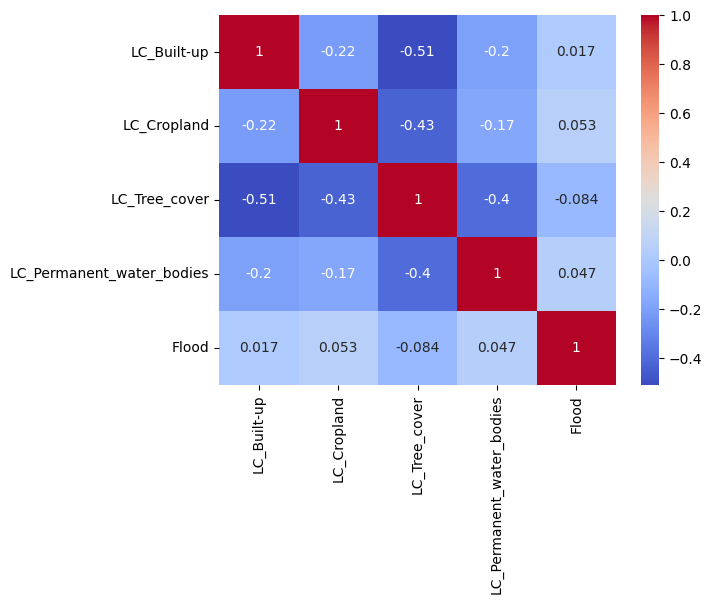

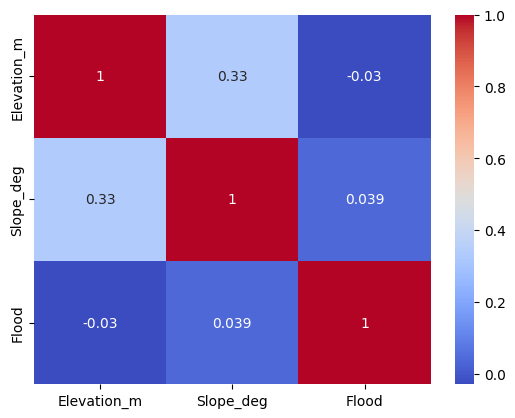

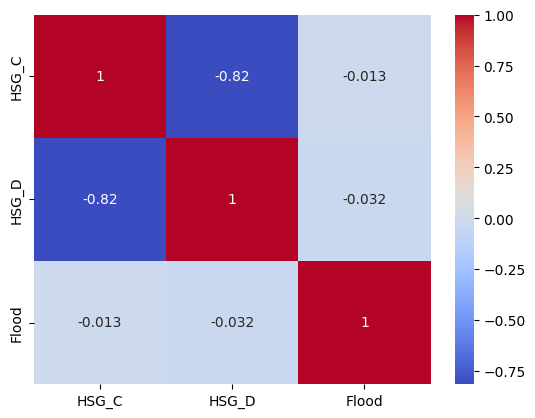

In [7]:
# Check the correlations between the sets of GIS 
landcover_cols = ["LC_" + label for label in df_landcover["LC_Label"].unique()]
elev_slope_cols = ["Elevation_m", "Slope_deg"]
hsg_cols = ['HSG_C', 'HSG_D']

# Check correlations
lcover_corr = env_floods[landcover_cols + ['Flood']].corr()
sns.heatmap(lcover_corr, annot=True, cmap='coolwarm')
plt.show()

elev_slope_corr = env_floods[elev_slope_cols + ['Flood']].corr()
sns.heatmap(elev_slope_corr, annot=True, cmap='coolwarm')
plt.show()

hsg_corr = env_floods[hsg_cols + ['Flood']].corr()
sns.heatmap(hsg_corr, annot=True, cmap='coolwarm')
plt.show()

In [8]:
# Save the augmented dataset
output_path = os.path.join("datasets", "floods_bangladesh_augmented.csv")
env_floods = env_floods.drop(columns=['LC_Class', 'HSG_Code'])
print(env_floods.columns)
env_floods.to_csv(output_path, index=False)

Index(['Station_Index', 'Station_Name', 'Year', 'Month', 'Max_Temp',
       'Min_Temp', 'Monthly_Rainfall', 'Relative_Humidity', 'Wind_Speed',
       'Cloud_Coverage', 'Hours_of_Sunshine', 'Station_Number', 'X_Coord',
       'Y_Coord', 'Latitude', 'Longitude', 'Year_Month', 'Flood',
       'Elevation_m', 'Slope_deg', 'LC_Built-up', 'LC_Cropland',
       'LC_Permanent_water_bodies', 'LC_Tree_cover', 'HSG_C', 'HSG_D'],
      dtype='object')
